In [1]:

import os
import pickle
import math
from pprint import pprint

import numpy as np
import pandas as pd

# ADJUST THIS PATH
GDV_PKL_PATH = "/Users/juliahagen/Vision-Transformers/res/gdv_500_0/gdv.pkl"

assert os.path.exists(GDV_PKL_PATH), f"File not found: {GDV_PKL_PATH}"
print("Using pickle:", GDV_PKL_PATH)

Using pickle: /Users/juliahagen/Vision-Transformers/res/gdv_500_0/gdv.pkl


In [2]:
# Cell 2: safe unpickler copied from the Dash app

class RemappingUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module.startswith("numpy._core"):
            module = module.replace("numpy._core", "numpy.core", 1)
        return super().find_class(module, name)

def load_pickle_remap(path: str):
    with open(path, "rb") as f:
        return RemappingUnpickler(f).load()

obj = load_pickle_remap(GDV_PKL_PATH)

print("Top-level keys:")
print(sorted(obj.keys()))

Top-level keys:
['gdv_per_layer', 'gdv_per_layer_cosine', 'layer_data', 'meta', 'sorted_layers']


In [3]:
# Cell 3: inspect structure

sorted_layers = obj.get("sorted_layers", [])
layer_data = obj.get("layer_data", {})
gdv_per_layer = obj.get("gdv_per_layer", {})

print("Number of sorted_layers:", len(sorted_layers))
print("Number of layer_data entries:", len(layer_data))
print("Number of gdv_per_layer entries:", len(gdv_per_layer))

print("\nFirst 5 sorted_layers:")
print(sorted_layers[:5])

if sorted_layers:
    first_key = sorted_layers[0]
    print("\nFirst layer key:", first_key)
    print("Keys inside layer_data[first_key]:")
    print(sorted(layer_data[first_key].keys()))

Number of sorted_layers: 82
Number of layer_data entries: 82
Number of gdv_per_layer entries: 82

First 5 sorted_layers:
['vision_0_D1408', 'vision_1_D1408', 'vision_2_D1408', 'vision_3_D1408', 'vision_4_D1408']

First layer key: vision_0_D1408
Keys inside layer_data[first_key]:
['gdv_cosine', 'gdv_euclidean', 'inter_cosine', 'inter_euclidean', 'intra_cosine', 'intra_euclidean', 'labels', 'layer_num', 'modality', 'pooling', 'projections', 'samples', 'samples_used', 'texts', 'tsne_runs', 'umap_runs', 'width_D', 'x', 'y']


In [4]:
# Cell 4: compare gdv_per_layer vs layer_data[layer]["gdv_euclidean"]

rows = []

for layer_key in sorted_layers:
    gdv_global = gdv_per_layer.get(layer_key, None)

    ld = layer_data.get(layer_key, {})
    gdv_local = ld.get("gdv_euclidean", None)

    same = False
    diff = None

    if gdv_global is not None and gdv_local is not None:
        try:
            gdv_global_f = float(gdv_global)
            gdv_local_f = float(gdv_local)
            same = math.isclose(gdv_global_f, gdv_local_f, rel_tol=1e-12, abs_tol=1e-12)
            diff = gdv_global_f - gdv_local_f
        except Exception:
            pass

    rows.append({
        "layer_key": layer_key,
        "gdv_per_layer": gdv_global,
        "gdv_layer_data": gdv_local,
        "same_exactish": same,
        "difference": diff,
        "has_gdv_per_layer": gdv_global is not None,
        "has_gdv_layer_data": gdv_local is not None,
    })

df_compare = pd.DataFrame(rows)
df_compare

,layer_key,gdv_per_layer,gdv_layer_data,same_exactish,difference,has_gdv_per_layer,has_gdv_layer_data
0,vision_0_D1408,-0.332566,-0.332566,True,0.0,True,True
1,vision_1_D1408,-0.340178,-0.340178,True,0.0,True,True
2,vision_2_D1408,-0.344854,-0.344854,True,0.0,True,True
3,vision_3_D1408,-0.347748,-0.347748,True,0.0,True,True
4,vision_4_D1408,-0.349181,-0.349181,True,0.0,True,True
...,...,...,...,...,...,...,...
77,language_43_D5120,-0.460623,-0.460623,True,0.0,True,True
78,language_44_D5120,-0.464332,-0.464332,True,0.0,True,True
79,language_45_D5120,-0.464737,-0.464737,True,0.0,True,True
80,language_46_D5120,-0.457685,-0.457685,True,0.0,True,True


In [5]:
# Cell 5: summarize what is going on

print("Layers with gdv_per_layer present:", df_compare["has_gdv_per_layer"].sum())
print("Layers with gdv_layer_data present:", df_compare["has_gdv_layer_data"].sum())
print("Layers where both are present:", ((df_compare["has_gdv_per_layer"]) & (df_compare["has_gdv_layer_data"])).sum())
print("Layers where values match:", df_compare["same_exactish"].sum())

print("\nRows where one side is missing or values differ:")
display(df_compare[
    (~df_compare["has_gdv_per_layer"]) |
    (~df_compare["has_gdv_layer_data"]) |
    (~df_compare["same_exactish"])
])

Layers with gdv_per_layer present: 82
Layers with gdv_layer_data present: 82
Layers where both are present: 82
Layers where values match: 82

Rows where one side is missing or values differ:


,layer_key,gdv_per_layer,gdv_layer_data,same_exactish,difference,has_gdv_per_layer,has_gdv_layer_data


In [14]:
# Check whether the needed fields are present in every layer
needed = ["width_D", "intra_euclidean", "inter_euclidean"]
check_rows = []

for layer_key in sorted_layers:
    ld = layer_data[layer_key]
    check_rows.append({
        "layer_key": layer_key,
        **{k: (k in ld) for k in needed},
        "has_labels": ("labels" in ld) or ("samples" in ld and "labels" in ld["samples"]),
    })

df_needed = pd.DataFrame(check_rows)
df_needed

,layer_key,width_D,intra_euclidean,inter_euclidean,has_labels
0,vision_0_D1408,True,True,True,True
1,vision_1_D1408,True,True,True,True
2,vision_2_D1408,True,True,True,True
3,vision_3_D1408,True,True,True,True
4,vision_4_D1408,True,True,True,True
...,...,...,...,...,...
77,language_43_D5120,True,True,True,True
78,language_44_D5120,True,True,True,True
79,language_45_D5120,True,True,True,True
80,language_46_D5120,True,True,True,True


In [15]:
# Recompute corrected GDV values from stored intra/inter/D only

import copy
import numpy as np
import pandas as pd

obj_fixed = copy.deepcopy(obj)

sorted_layers = obj_fixed["sorted_layers"]
layer_data = obj_fixed["layer_data"]

recalc_rows = []

for layer_key in sorted_layers:
    ld = layer_data[layer_key]

    D = int(ld["width_D"])
    intra = float(ld["intra_euclidean"])
    inter = float(ld["inter_euclidean"])

    # get labels for K
    if "samples" in ld and "labels" in ld["samples"]:
        labels = np.array(ld["samples"]["labels"], dtype=object)
    else:
        labels = np.array(ld.get("labels", []), dtype=object)

    labels_norm = np.array([str(x).strip().lower() for x in labels], dtype=object)
    K = len(np.unique(labels_norm))

    old_gdv = float(ld.get("gdv_euclidean", np.nan))

    if K < 2:
        new_gdv = 0.0
        formula_used = "degenerate"
    elif K == 2:
        new_gdv = (intra - inter) / np.sqrt(D)
        formula_used = "centered_2class"
    else:
        new_gdv = (1 / np.sqrt(D)) * ((1 / K) * intra - (2 / (K * (K - 1))) * inter)
        formula_used = "original_K_weighted"

    # write back
    ld["gdv_euclidean"] = float(new_gdv)
    obj_fixed["gdv_per_layer"][layer_key] = float(new_gdv)

    recalc_rows.append({
        "layer_key": layer_key,
        "K": K,
        "width_D": D,
        "intra_euclidean": intra,
        "inter_euclidean": inter,
        "old_gdv": old_gdv,
        "new_gdv": new_gdv,
        "delta": new_gdv - old_gdv,
        "formula_used": formula_used,
    })

df_recalc = pd.DataFrame(recalc_rows)
df_recalc

,layer_key,K,width_D,intra_euclidean,inter_euclidean,old_gdv,new_gdv,delta,formula_used
0,vision_0_D1408,2,1408,24.916196,24.937070,-0.332566,-0.000556,0.332009,centered_2class
1,vision_1_D1408,2,1408,25.487627,25.508431,-0.340178,-0.000554,0.339624,centered_2class
2,vision_2_D1408,2,1408,25.850007,25.865071,-0.344854,-0.000401,0.344452,centered_2class
3,vision_3_D1408,2,1408,26.074229,26.085767,-0.347748,-0.000307,0.347440,centered_2class
4,vision_4_D1408,2,1408,26.172814,26.188830,-0.349181,-0.000427,0.348754,centered_2class
...,...,...,...,...,...,...,...,...,...
77,language_43_D5120,2,5120,45.316672,55.617832,-0.460623,-0.143963,0.316660,centered_2class
78,language_44_D5120,2,5120,45.156219,55.802983,-0.464332,-0.148793,0.315539,centered_2class
79,language_45_D5120,2,5120,44.656776,55.582242,-0.464737,-0.152688,0.312049,centered_2class
80,language_46_D5120,2,5120,44.455502,54.977039,-0.457685,-0.147043,0.310642,centered_2class


In [16]:
# Optional: recompute cosine GDV too

if "gdv_per_layer_cosine" in obj_fixed:
    for layer_key in sorted_layers:
        ld = layer_data[layer_key]

        if "intra_cosine" not in ld or "inter_cosine" not in ld:
            continue

        D = int(ld["width_D"])
        intra = float(ld["intra_cosine"])
        inter = float(ld["inter_cosine"])

        if "samples" in ld and "labels" in ld["samples"]:
            labels = np.array(ld["samples"]["labels"], dtype=object)
        else:
            labels = np.array(ld.get("labels", []), dtype=object)

        labels_norm = np.array([str(x).strip().lower() for x in labels], dtype=object)
        K = len(np.unique(labels_norm))

        if K < 2:
            new_gdv = 0.0
        elif K == 2:
            new_gdv = (intra - inter) / np.sqrt(D)
        else:
            new_gdv = (1 / np.sqrt(D)) * ((1 / K) * intra - (2 / (K * (K - 1))) * inter)

        ld["gdv_cosine"] = float(new_gdv)
        obj_fixed["gdv_per_layer_cosine"][layer_key] = float(new_gdv)

In [17]:
# Save corrected pickle to a new file first
GDV_PKL_FIXED_PATH = GDV_PKL_PATH.replace(".pkl", "_fixed.pkl")

with open(GDV_PKL_FIXED_PATH, "wb") as f:
    pickle.dump(obj_fixed, f)

print("Saved corrected pickle to:", GDV_PKL_FIXED_PATH)

Saved corrected pickle to: /Users/juliahagen/Vision-Transformers/res/gdv_500_0/gdv_fixed.pkl


In [18]:
import os
import pickle
import pandas as pd

GDV_PKL_PATH = "/Users/juliahagen/Vision-Transformers/res/gdv_500_0/gdv.pkl"
GDV_CSV_PATH = "/Users/juliahagen/Vision-Transformers/res/gdv_500_0/gdv_values.csv"

class RemappingUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module.startswith("numpy._core"):
            module = module.replace("numpy._core", "numpy.core", 1)
        return super().find_class(module, name)

def load_pickle_remap(path: str):
    with open(path, "rb") as f:
        return RemappingUnpickler(f).load()

obj = load_pickle_remap(GDV_PKL_PATH)

rows = []
for layer_key in obj["sorted_layers"]:
    ld = obj["layer_data"][layer_key]
    rows.append({
        "Modality": ld.get("modality"),
        "Layer_Num": ld.get("layer_num"),
        "Width_D": ld.get("width_D"),
        "LayerKey": layer_key,
        "GDV_Euclidean": ld.get("gdv_euclidean"),
        "Intra_Euclidean": ld.get("intra_euclidean"),
        "Inter_Euclidean": ld.get("inter_euclidean"),
        "GDV_Cosine": ld.get("gdv_cosine"),
        "Intra_Cosine": ld.get("intra_cosine"),
        "Inter_Cosine": ld.get("inter_cosine"),
        "Pooling": ld.get("pooling"),
        "Samples_Used": ld.get("samples_used"),
    })

df = pd.DataFrame(rows)
df.to_csv(GDV_CSV_PATH, index=False)

print(f"Saved updated CSV to: {GDV_CSV_PATH}")
df.head()

Saved updated CSV to: /Users/juliahagen/Vision-Transformers/res/gdv_500_0/gdv_values.csv


,Modality,Layer_Num,Width_D,LayerKey,GDV_Euclidean,Intra_Euclidean,Inter_Euclidean,GDV_Cosine,Intra_Cosine,Inter_Cosine,Pooling,Samples_Used
0,vision,0,1408,vision_0_D1408,-0.000556,24.916196,24.937070,-0.000080,0.987600,0.990594,Vector,461
1,vision,1,1408,vision_1_D1408,-0.000554,25.487627,25.508431,-0.000073,0.992398,0.995154,Vector,461
2,vision,2,1408,vision_2_D1408,-0.000401,25.850007,25.865071,-0.000046,0.995413,0.997150,Vector,461
3,vision,3,1408,vision_3_D1408,-0.000307,26.074229,26.085767,-0.000036,0.996913,0.998247,Vector,461
4,vision,4,1408,vision_4_D1408,-0.000427,26.172814,26.188830,-0.000048,0.998055,0.999865,Vector,461


# Check GDV integrity on Gaussians

In [6]:
import importlib.util
import os

GDV_FILE = "/Users/juliahagen/Vision-Transformers/metrics/gdv_experiments.py"

spec = importlib.util.spec_from_file_location("gdv_experiments_module", GDV_FILE)
gdv_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(gdv_mod)

compute_gdv = gdv_mod.compute_gdv
compute_mean_intra_class_distance = gdv_mod.compute_mean_intra_class_distance
compute_mean_inter_class_distance = gdv_mod.compute_mean_inter_class_distance

In [7]:
# Cell 1: imports for the sanity check

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [8]:
# Cell 2: helper to generate two Gaussian classes

def make_two_gaussians(
    n_per_class=300,
    dim=64,
    mean_offset=0.0,
    std=1.0,
    random_state=42,
):
    """
    Two Gaussian clouds in R^dim.
    Class B is shifted along the first axis by mean_offset.
    """
    rng = np.random.default_rng(random_state)

    mean_a = np.zeros(dim)
    mean_b = np.zeros(dim)
    mean_b[0] = mean_offset

    cov = (std ** 2) * np.eye(dim)

    Xa = rng.multivariate_normal(mean=mean_a, cov=cov, size=n_per_class)
    Xb = rng.multivariate_normal(mean=mean_b, cov=cov, size=n_per_class)

    X = np.vstack([Xa, Xb])
    labels = np.array(["A"] * n_per_class + ["B"] * n_per_class)

    return X, labels

In [9]:
# Cell 3: quick PCA visualization helper

def plot_gaussians(X, labels, title="Gaussian sanity check"):
    X2 = PCA(n_components=2).fit_transform(X)

    plt.figure(figsize=(6, 6))
    for lab in np.unique(labels):
        m = labels == lab
        plt.scatter(X2[m, 0], X2[m, 1], alpha=0.7, label=lab)

    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [10]:
# Cell 4: helper that mirrors compute_gdv internals so we can inspect intra/inter

def zscore_like_gdv(X):
    mu = X.mean(axis=0, keepdims=True)
    sigma = X.std(axis=0, keepdims=True) + 1e-12
    Xz = (X - mu) / sigma
    Xz *= 0.5
    return Xz

def inspect_gdv(X, labels):
    Xz = zscore_like_gdv(X)

    intra = compute_mean_intra_class_distance(Xz, labels)
    inter = compute_mean_inter_class_distance(Xz, labels)
    gdv = compute_gdv(X, labels)

    return {
        "n_samples": X.shape[0],
        "dim": X.shape[1],
        "intra_z": intra,
        "inter_z": inter,
        "gdv": gdv,
    }

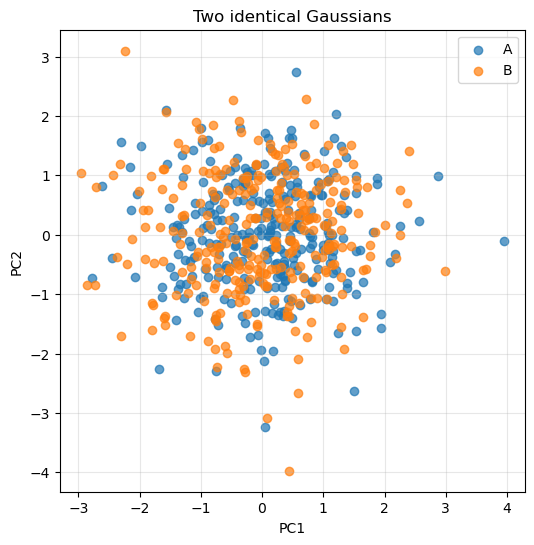

Unique labels: ['a' 'b'], Counts: [300 300]
Label: a, Indices: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 

,n_samples,dim,intra_z,inter_z,gdv
0,600,2,0.884431,0.884232,0.000141


In [11]:
# Cell 5: test 1 — same distribution

X_same, y_same = make_two_gaussians(
    n_per_class=300,
    dim=2,
    mean_offset=0.0,
    std=1.0,
    random_state=1,
)

plot_gaussians(X_same, y_same, title="Two identical Gaussians")

res_same = inspect_gdv(X_same, y_same)
pd.DataFrame([res_same])

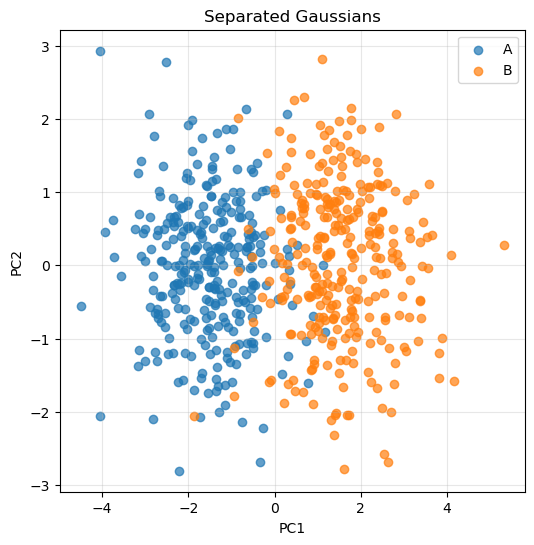

Unique labels: ['a' 'b'], Counts: [300 300]
Label: a, Indices: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 

,n_samples,dim,intra_z,inter_z,gdv
0,600,2,0.698481,1.089095,-0.276205


In [12]:
# Cell 6: test 2 — separated Gaussians

X_sep, y_sep = make_two_gaussians(
    n_per_class=300,
    dim=2,
    mean_offset=3.0,
    std=1.0,
    random_state=1,
)

plot_gaussians(X_sep, y_sep, title="Separated Gaussians")

res_sep = inspect_gdv(X_sep, y_sep)
pd.DataFrame([res_sep])

In [13]:
# Cell 7: compare the two cases directly

df_compare = pd.DataFrame([
    {"case": "same_distribution", **res_same},
    {"case": "separated", **res_sep},
])

df_compare

,case,n_samples,dim,intra_z,inter_z,gdv
0,same_distribution,600,2,0.884431,0.884232,0.000141
1,separated,600,2,0.698481,1.089095,-0.276205
